# Architecture

In [27]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import models


# ======================
# ASPP (FIXED + IMPROVED)
# ======================
class ASPP(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels, out_channels, 1, bias=False)
        self.conv2 = nn.Conv2d(in_channels, out_channels, 3, padding=6, dilation=6, bias=False)
        self.conv3 = nn.Conv2d(in_channels, out_channels, 3, padding=12, dilation=12, bias=False)

        # Global context branch
        self.global_pool = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(in_channels, out_channels, 1, bias=False),
            nn.ReLU(inplace=True)
        )

        # ✅ FIX: 4 branches → 4 * out_channels
        self.bn = nn.GroupNorm(32, out_channels * 4)
        self.relu = nn.ReLU(inplace=True)

        self.project = nn.Sequential(
            nn.Conv2d(out_channels * 4, out_channels, 1, bias=False),
            nn.GroupNorm(32, out_channels),
            nn.ReLU(inplace=True),
            nn.Dropout(0.3)
        )

    def forward(self, x):
        x1 = self.conv1(x)
        x2 = self.conv2(x)
        x3 = self.conv3(x)

        x4 = self.global_pool(x)
        x4 = F.interpolate(x4, size=x.shape[-2:], mode='bilinear', align_corners=True)

        out = torch.cat([x1, x2, x3, x4], dim=1)

        out = self.relu(self.bn(out))
        return self.project(out)


# ======================
# SE BLOCK (Stable)
# ======================
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=16):
        super().__init__()

        self.se = nn.Sequential(
            nn.AdaptiveAvgPool2d(1),
            nn.Conv2d(channels, channels // reduction, 1),
            nn.ReLU(inplace=True),
            nn.Conv2d(channels // reduction, channels, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return x * self.se(x)


# ======================
# DECODER BLOCK (UPGRADED)
# ======================
class DecoderBlock(nn.Module):
    def __init__(self, in_channels, skip_channels, out_channels):
        super().__init__()

        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels + skip_channels, out_channels, 3, padding=1, bias=False),
            nn.GroupNorm(16, out_channels),
            nn.ReLU(inplace=True)
        )

        self.se = SEBlock(out_channels)

        self.conv2 = nn.Sequential(
            nn.Conv2d(out_channels, out_channels, 3, padding=1, bias=False),
            nn.GroupNorm(16, out_channels),
            nn.ReLU(inplace=True)
        )

        # 🔥 residual connection for stability
        self.residual = nn.Conv2d(in_channels + skip_channels, out_channels, 1, bias=False)

    def forward(self, x, skip):
        if x.shape[-2:] != skip.shape[-2:]:
            x = F.interpolate(x, size=skip.shape[-2:], mode='bilinear', align_corners=True)

        x_cat = torch.cat([x, skip], dim=1)

        out = self.conv1(x_cat)
        out = self.se(out)
        out = self.conv2(out)

        res = self.residual(x_cat)

        return out + res


# ======================
# MAIN MODEL
# ======================
class FastResUNet(nn.Module):
    def __init__(self, num_classes=21):
        super().__init__()

        # ===== ENCODER =====
        resnet = models.resnet18(weights='IMAGENET1K_V1')

        self.layer0 = nn.Sequential(resnet.conv1, resnet.bn1, resnet.relu)  # 1/2
        self.pool = resnet.maxpool
        self.layer1 = resnet.layer1  # 1/4
        self.layer2 = resnet.layer2  # 1/8
        self.layer3 = resnet.layer3  # 1/16
        self.layer4 = resnet.layer4  # 1/32

        # Freeze early layers
        for p in self.layer0.parameters(): p.requires_grad = False
        for p in self.layer1.parameters(): p.requires_grad = False

        # ===== BOTTLENECK =====
        self.aspp = ASPP(512, 256)

        # ===== DECODER =====
        self.up1 = nn.ConvTranspose2d(256, 256, 2, stride=2)
        self.dec1 = DecoderBlock(256, 256, 128)

        self.up2 = nn.ConvTranspose2d(128, 128, 2, stride=2)
        self.dec2 = DecoderBlock(128, 128, 64)

        self.up3 = nn.ConvTranspose2d(64, 64, 2, stride=2)
        self.dec3 = DecoderBlock(64, 64, 64)

        self.up4 = nn.ConvTranspose2d(64, 32, 2, stride=2)
        self.dec4 = DecoderBlock(32, 64, 32)

        # 🔥 Better final head
        self.final = nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True),
            nn.Conv2d(32, 32, 3, padding=1, bias=False),
            nn.GroupNorm(8, 32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, num_classes, 1)
        )

    def forward(self, x):
        # Encoder
        l0 = self.layer0(x)
        l1 = self.layer1(self.pool(l0))
        l2 = self.layer2(l1)
        l3 = self.layer3(l2)
        l4 = self.layer4(l3)

        # Bottleneck
        bottleneck = self.aspp(l4)

        # Decoder
        d1 = self.up1(bottleneck)
        d1 = self.dec1(d1, l3)

        d2 = self.up2(d1)
        d2 = self.dec2(d2, l2)

        d3 = self.up3(d2)
        d3 = self.dec3(d3, l1)

        d4 = self.up4(d3)
        d4 = self.dec4(d4, l0)

        return self.final(d4)

In [28]:
device = torch.device("xpu" if torch.xpu.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


# Training Loop

In [31]:
import os
import torch
import torch.nn as nn
from tqdm import tqdm
import numpy as np
from my_dataset import get_dataloader
import torch.nn.functional as F

# --- 1. Custom Loss Function ---
class DiceCELoss(nn.Module):
    def __init__(self, num_classes=21, ignore_index=255, ce_weights=None):
        super().__init__()
        self.ce = nn.CrossEntropyLoss(weight=ce_weights, ignore_index=ignore_index)
        self.num_classes = num_classes
        self.ignore_index = ignore_index

    def forward(self, inputs, targets):
        # 1. Standard Cross Entropy Loss (already handles ignore_index natively)
        ce_loss = self.ce(inputs, targets)

        # 2. Vectorized Dice Loss
        probs = torch.softmax(inputs, dim=1)  # (B, C, H, W)

        # Create mask for valid pixels (B, 1, H, W)
        valid_mask = (targets != self.ignore_index).unsqueeze(1) 

        # --- THE FIX ---
        # Clone targets and replace the 255 ignore_index with a safe index (0) 
        # so scatter_ doesn't throw an out-of-bounds error.
        safe_targets = targets.clone()
        safe_targets[targets == self.ignore_index] = 0

        # One-hot encode targets safely
        targets_onehot = torch.zeros_like(probs)
        targets_onehot.scatter_(1, safe_targets.unsqueeze(1), 1)

        # Apply valid mask (This zeroes out all the "fake" 0s we just added for ignored pixels)
        probs = probs * valid_mask
        targets_onehot = targets_onehot * valid_mask

        # Compute Dice
        dims = (0, 2, 3)  # sum over batch + spatial
        intersection = (probs * targets_onehot).sum(dims)
        union = probs.sum(dims) + targets_onehot.sum(dims)

        dice = (2. * intersection + 1e-8) / (union + 1e-8)
        dice_loss = 1 - dice.mean()

        return ce_loss + dice_loss
    
class CombinedLoss(nn.Module):
    def __init__(self, num_classes=21, ignore_index=255, ce_weights=None, boundary_weight=0.1):
        super().__init__()
        self.main_loss = DiceCELoss(num_classes, ignore_index, ce_weights)
        self.boundary_weight = boundary_weight

    def forward(self, outputs, targets):
        loss_main = self.main_loss(outputs, targets)
        loss_boundary = boundary_loss(outputs, targets)

        return loss_main + self.boundary_weight * loss_boundary
    

def boundary_loss(preds, targets):
    preds = torch.softmax(preds, dim=1)
    preds = torch.argmax(preds, dim=1).float()

    kernel = torch.tensor([[0,1,0],[1,-4,1],[0,1,0]], dtype=torch.float32)\
                .unsqueeze(0).unsqueeze(0).to(preds.device)

    preds_edge = F.conv2d(preds.unsqueeze(1), kernel, padding=1).abs()
    targets_edge = F.conv2d(targets.unsqueeze(1).float(), kernel, padding=1).abs()

    return F.l1_loss(preds_edge, targets_edge)
# --- 2. Metrics Calculation ---
def calculate_metrics(preds, masks, num_classes=21, ignore_index=255):
    preds = torch.argmax(preds, dim=1)
    valid = masks != ignore_index
    preds = preds[valid]
    masks = masks[valid]
    
    acc = (preds == masks).float().mean().item() if len(preds) > 0 else 0.0
    
    ious = []
    for cls in range(num_classes):
        pred_inds = (preds == cls)
        target_inds = (masks == cls)
        intersection = (pred_inds & target_inds).sum().item()
        union = (pred_inds | target_inds).sum().item()
        if union > 0:
            ious.append(intersection / union)
            
    miou = np.mean(ious) if ious else 0.0
    return acc, miou

# --- 3. Training & Validation Steps ---
def train_one_epoch(model, dataloader, optimizer, scheduler, criterion, device, accum_steps):
    model.train()
    running_loss, running_acc, running_miou = 0.0, 0.0, 0.0
    
    optimizer.zero_grad() 
    
    pbar = tqdm(dataloader, desc="Training")
    for i, (images, masks) in enumerate(pbar):
        images, masks = images.to(device), masks.to(device)

        outputs = model(images)
        loss = criterion(outputs, masks)
        
        # Gradient Accumulation (Helps simulate larger batch sizes on CPU)
        (loss / accum_steps).backward() 
        
        if (i + 1) % accum_steps == 0 or (i + 1) == len(dataloader):
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step() # Step OneCycleLR per batch
            optimizer.zero_grad()

        # acc, miou = calculate_metrics(outputs, masks)   # Commenting out metric calculations to speed up training on CPU
        
        running_loss += loss.item()
        # running_acc += acc        # Commenting out accuracy accumulation to speed up training on CPU
        # running_miou += miou      # Commenting out mIoU accumulation to speed up training on CPU
        pbar.set_postfix(Loss=loss.item())

    return running_loss/len(dataloader), running_acc/len(dataloader), running_miou/len(dataloader)

def validate(model, dataloader, criterion, device):
    model.eval()
    val_loss, val_acc, val_miou = 0.0, 0.0, 0.0
    
    with torch.no_grad():
        for images, masks in tqdm(dataloader, desc="Validating"):
            images, masks = images.to(device), masks.to(device)
            outputs = model(images)
            loss = criterion(outputs, masks)
            
            acc, miou = calculate_metrics(outputs, masks)
            
            val_loss += loss.item()
            val_acc += acc
            val_miou += miou
            
    return val_loss/len(dataloader), val_acc/len(dataloader), val_miou/len(dataloader)

# --- 4. Main Execution ---
def main():
    # --- CONFIGURATION ---
    DATA_PATH = "./Pascal_VOC_2012/VOC2012_train_val/VOC2012_train_val" # UPDATE THIS
    BATCH_SIZE = 4 
    ACCUMULATION_STEPS = 4 # Simulates a batch size of 16
    MAX_LR = 5e-4 
    EPOCHS = 200
    PATIENCE = 30 
    IMG_SIZE = (448, 448) # Increased resolution for better spatial detail
    
    CHECKPOINT_PATH = "latest_fast_checkpoint.pth"
    BEST_MODEL_PATH = "best_fast_model.pth"
    
    device = torch.device("cpu") # Forcing CPU as requested
    print(f"--- Running on: {device} ---")

    # Initialize Dataloaders
    train_loader, val_loader = get_dataloader(DATA_PATH, batch_size=BATCH_SIZE, img_size=IMG_SIZE)
    
    # Initialize Model
    model = FastResUNet(num_classes=21).to(device)
    
    # Downweight background class to force model to focus on objects
    class_weights = torch.ones(21).to(device)
    class_weights[0] = 0.1 
    criterion = CombinedLoss(
    num_classes=21,
    ignore_index=255,
    ce_weights=class_weights,
    boundary_weight=0.2) # Keeping boundary loss for better edge learning, can be set to 0 if too slow on CPU
    
    # --- DIFFERENTIAL LEARNING RATES ---
    # ResNet backbone gets a lower learning rate, ASPP/Decoder get the max LR
    backbone_params = [p for n, p in model.named_parameters() if 'layer' in n and p.requires_grad]
    head_params = [p for n, p in model.named_parameters() if 'layer' not in n and p.requires_grad]
    
    optimizer = torch.optim.AdamW([
        {'params': backbone_params, 'lr': MAX_LR / 10},
        {'params': head_params, 'lr': MAX_LR}
    ], weight_decay=1e-2)
    
    total_steps = (len(train_loader) // ACCUMULATION_STEPS) * EPOCHS
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer, max_lr=[MAX_LR / 10, MAX_LR], total_steps=total_steps, pct_start=0.1
    )

    # --- Checkpoint Loading ---
    start_epoch = 0
    best_val_miou = 0.0
    patience_counter = 0

    if os.path.exists(CHECKPOINT_PATH):
        print(f"🔄 Found checkpoint '{CHECKPOINT_PATH}'. Resuming training...")
        checkpoint = torch.load(CHECKPOINT_PATH, map_location=device)
        model.load_state_dict(checkpoint['model_state_dict'])
        optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        scheduler.load_state_dict(checkpoint['scheduler_state_dict'])
        start_epoch = checkpoint['epoch'] + 1
        best_val_miou = checkpoint.get('best_val_miou', 0.0)
        patience_counter = checkpoint.get('patience_counter', 0)
        print(f"✅ Resumed from epoch {start_epoch} (Best Val mIoU so far: {best_val_miou:.4f})")
    else:
        print("🚀 No checkpoint found. Starting training from scratch.")

    # --- Training Loop ---
    for epoch in range(start_epoch, EPOCHS):
        print(f"\nEpoch {epoch+1}/{EPOCHS}")
        
        t_loss, t_acc, t_miou = train_one_epoch(model, train_loader, optimizer, scheduler, criterion, device, ACCUMULATION_STEPS)
        v_loss, v_acc, v_miou = validate(model, val_loader, criterion, device)
        
        current_lr_head = optimizer.param_groups[1]['lr']
        print(f"Train - Loss: {t_loss:.4f} | Acc: {t_acc:.4f} | mIoU: {t_miou:.4f}")
        print(f"Val   - Loss: {v_loss:.4f} | Acc: {v_acc:.4f} | mIoU: {v_miou:.4f} | Head LR: {current_lr_head:.6f}")
        
        # Early Stopping based on mIoU
        if v_miou > best_val_miou:
            best_val_miou = v_miou
            patience_counter = 0
            torch.save(model.state_dict(), BEST_MODEL_PATH)
            print(f"🌟 New best model saved! (mIoU: {best_val_miou:.4f}) 🌟")
        else:
            patience_counter += 1
            print(f"⚠️ No improvement in mIoU. Early stopping patience: {patience_counter}/{PATIENCE}")
            
        # Save Latest Checkpoint Every Epoch
        checkpoint_dict = {
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'best_val_miou': best_val_miou,
            'patience_counter': patience_counter
        }
        torch.save(checkpoint_dict, CHECKPOINT_PATH)
        # if epoch > 90== 0:
        #     epoch = 0

        if patience_counter >= PATIENCE:
            print(f"🛑 Early stopping triggered after {epoch+1} epochs!")
            break


if __name__ == "__main__":
    main()
#

--- Running on: cpu ---
🔄 Found checkpoint 'latest_fast_checkpoint.pth'. Resuming training...


C:\Users\tanish\AppData\Local\Temp\ipykernel_1308\3526304247.py:200: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(CHECKPOINT_PATH, map_location=devi

✅ Resumed from epoch 75 (Best Val mIoU so far: 0.4553)

Epoch 76/200


Validating: 100%|██████████| 363/363 [09:42<00:00,  1.61s/it]


Train - Loss: 3.2706 | Acc: 0.0000 | mIoU: 0.0000
Val   - Loss: 3.8490 | Acc: 0.8928 | mIoU: 0.4555 | Head LR: 0.000387
🌟 New best model saved! (mIoU: 0.4555) 🌟

Epoch 77/200


...

Train - Loss: 3.2611 | Acc: 0.0000 | mIoU: 0.0000
Val   - Loss: 3.8330 | Acc: 0.8952 | mIoU: 0.4121 | Head LR: 0.000331
⚠️ No improvement in mIoU. Early stopping patience: 6/30

Epoch 91/200


Validating: 100%|██████████| 363/363 [08:51<00:00,  1.47s/it]


Train - Loss: 3.2768 | Acc: 0.0000 | mIoU: 0.0000
Val   - Loss: 3.9057 | Acc: 0.8943 | mIoU: 0.4155 | Head LR: 0.000327
⚠️ No improvement in mIoU. Early stopping patience: 7/30

Epoch 92/200


Training:  79%|███████▉  | 290/366 [15:32<04:04,  3.22s/it, Loss=3.2] 


KeyboardInterrupt: 

# Testing & Inference

In [ ]:
# Have to add Data Augmentation (RandomHorizontalFlip, RandomCrop, SaltPepperNoise, BlackandWhite) to the training dataset to improve generalization.

Loading model from ./best_resvit_model.pth onto cpu...


C:\Users\tanish\AppData\Local\Temp\ipykernel_20012\589718827.py:19: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load(model_path, map_location=d

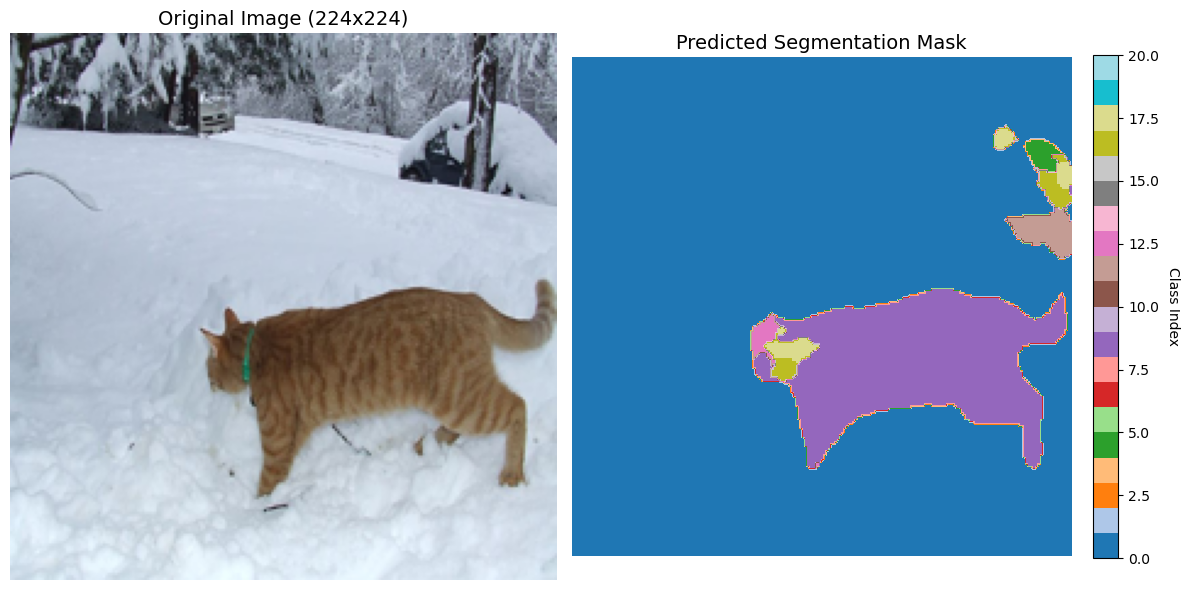

In [38]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from torchvision import transforms
from PIL import Image

# IMPORTANT: Make sure the FastResUNet class is already defined or imported in your notebook
# before running this cell!

def visualize_prediction(image_path, model_path, device="cpu"):
    """
    Loads a trained model, runs inference on a single image, and plots the result.
    """
    print(f"Loading model from {model_path} onto {device}...")
    
    # 1. Initialize Model and Load Weights
    model = FastResUNet(num_classes=21).to(device)
    # map_location ensures it loads correctly even if you trained on XPU/GPU and test on CPU
    model.load_state_dict(torch.load(model_path, map_location=device))
    model.eval() # Set to evaluation mode!

    # 2. Image Transformations (Must match training!)
    # We don't need the mask transform here since we are predicting it
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    # 3. Load and Prepare the Image
    img_pil = Image.open(image_path).convert("RGB")
    
    # Apply transforms and add the batch dimension: (1, 3, 160, 160)
    input_tensor = transform(img_pil).unsqueeze(0).to(device)

    # 4. Run Inference
    with torch.no_grad():
        output = model(input_tensor) # Shape: (1, 21, 160, 160)
        
        # We want the class with the highest score for each pixel
        # argmax across the channel dimension (dim=1)
        pred_mask = torch.argmax(output, dim=1).squeeze(0).cpu().numpy()

    # 5. Visualization
    fig, axes = plt.subplots(1, 2, figsize=(12, 6))

    # Plot Original Image (resized to match the mask)
    axes[0].imshow(img_pil.resize((224, 224)))
    axes[0].set_title("Original Image (224x224)", fontsize=14)
    axes[0].axis('off')

    # Plot Predicted Mask
    # 'tab20' is a great colormap for segmentation because it has distinct colors for different classes
    mask_plot = axes[1].imshow(pred_mask, cmap='tab20', vmin=0, vmax=20)
    axes[1].set_title("Predicted Segmentation Mask", fontsize=14)
    axes[1].axis('off')
    
    # Add a colorbar to see which colors map to which class indices
    cbar = plt.colorbar(mask_plot, ax=axes[1], fraction=0.046, pad=0.04)
    cbar.set_label('Class Index', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()

# --- Execution ---
# --- Execution ---
if __name__ == "__main__":
    # Detect device
    device = torch.device("xpu" if torch.xpu.is_available() else "cpu")
    
    # --- UPDATE THESE PATHS ---
    MY_MODEL_WEIGHTS = "./best_fastresunet_model.pth" 
    
    # FIXED: Now pointing to the unseen test dataset!
    # Pick a random image from your test folder to evaluate
    TEST_IMAGE_PATH = "./Pascal_VOC_2012/VOC2012_test/VOC2012_test/JPEGImages/2008_000017.jpg" 
    
    visualize_prediction(TEST_IMAGE_PATH, MY_MODEL_WEIGHTS, device)